Importing libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

import warnings
warnings.filterwarnings('ignore')

Loading the dataset

In [2]:
df = pd.read_csv("Sales - Marketing customer dataset.csv")

Getting the primary info from the dataset

In [3]:
print("Dataset shape:", df.shape)
display(df.head())
display(df.info())

Dataset shape: (15000, 30)


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

None

Identifying the data quality problems

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

print("\nUnique values:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Rows: 15000
Columns: 30

Data types:
customer_id                     int64
gender                         object
age                           float64
country                        object
city                           object
signup_date                    object
last_purchase_date             object
acquisition_channel            object
device_type                    object
subscription_type              object
is_premium_user                 int64
total_visits                    int64
avg_session_time              float64
pages_per_session             float64
email_open_rate               float64
email_click_rate              float64
total_spent                   float64
avg_order_value               float64
discount_used                   int64
coupon_code                    object
support_tickets                 int64
refund_requested                int64
delivery_delay_days             int64
payment_method                 object
satisfaction_score            float64
nps_score    

Checking the age column

In [5]:
invalid_age = df[(df["age"] < 18) | (df["age"] > 100)]

print("Invalid ages:", len(invalid_age))
print(invalid_age["age"].value_counts().sort_index())

Invalid ages: 516
age
-4.0       1
-2.0       1
-1.0       1
 0.0       1
 2.0       6
 3.0       2
 4.0       3
 5.0       8
 6.0       9
 7.0      15
 8.0       9
 9.0      17
 10.0     22
 11.0     31
 12.0     43
 13.0     45
 14.0     44
 15.0     76
 16.0     79
 17.0    103
Name: count, dtype: int64


From the  cell above we can notice that there are 516 invalid ages, there are even negative ages,that's a data quality problem

Now, looking for data inconsistency

In [6]:
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["last_purchase_date"] = pd.to_datetime(df["last_purchase_date"])

invalid_dates = df[
    df["signup_date"] > df["last_purchase_date"]
]

print("Signup after last purchase:", len(invalid_dates))

Signup after last purchase: 3762


The above cell shows the date inconsistencies

In [7]:
country_city = pd.crosstab(df["country"], df["city"])

display(country_city)

city,Berlin,Delhi,Dhaka,Hamburg,London,Mumbai,New York
country,,,,,,,
Bangladesh,400,409,441,416,447,444,427
Germany,431,425,441,447,430,470,428
India,438,438,403,385,456,443,451
UK,422,402,436,454,445,389,407
USA,384,454,457,362,458,438,422


The above cell shows the country and cities which are geographically incorrect thus inconsistency

Now, looking for the duplicates in our dataset

In [8]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


The above cell, shows to us that there are infact 0(none) duplicates

Calculating missing value percentages

In [9]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing = missing[missing["Missing_Count"] > 0]
missing = missing.sort_values("Missing_Percentage", ascending=False)

print(missing)

                    Missing_Count  Missing_Percentage
coupon_code                  6133           40.886667
age                          1200            8.000000
total_spent                  1050            7.000000
gender                        738            4.920000
satisfaction_score            702            4.680000


Investigating outliers and extreme values

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outliers": count
    })

outliers = pd.DataFrame(outlier_summary)

display(
    outliers.sort_values(
        "Outliers",
        ascending=False
    )
)

,Feature,Lower_Bound,Upper_Bound,Outliers
19,churn,0.000000,0.000000,2298
12,refund_requested,0.000000,0.000000,2215
14,satisfaction_score,1.500000,5.500000,753
13,delivery_delay_days,-1.000000,7.000000,184
1,age,7.000000,63.000000,89
11,support_tickets,-2.000000,6.000000,79
8,total_spent,-302.514767,1305.343477,78
17,lifetime_value,-663.537470,3082.699120,56
9,avg_order_value,-7.751493,127.672408,54
4,avg_session_time,-0.153592,16.188132,45


The above cell shows us that there are such outliers and extreme values, i.e having the 89th percentile that's extreme, but we do not remove them yet since we are asked to just investigate and not remove

Visualizing important numeric variables

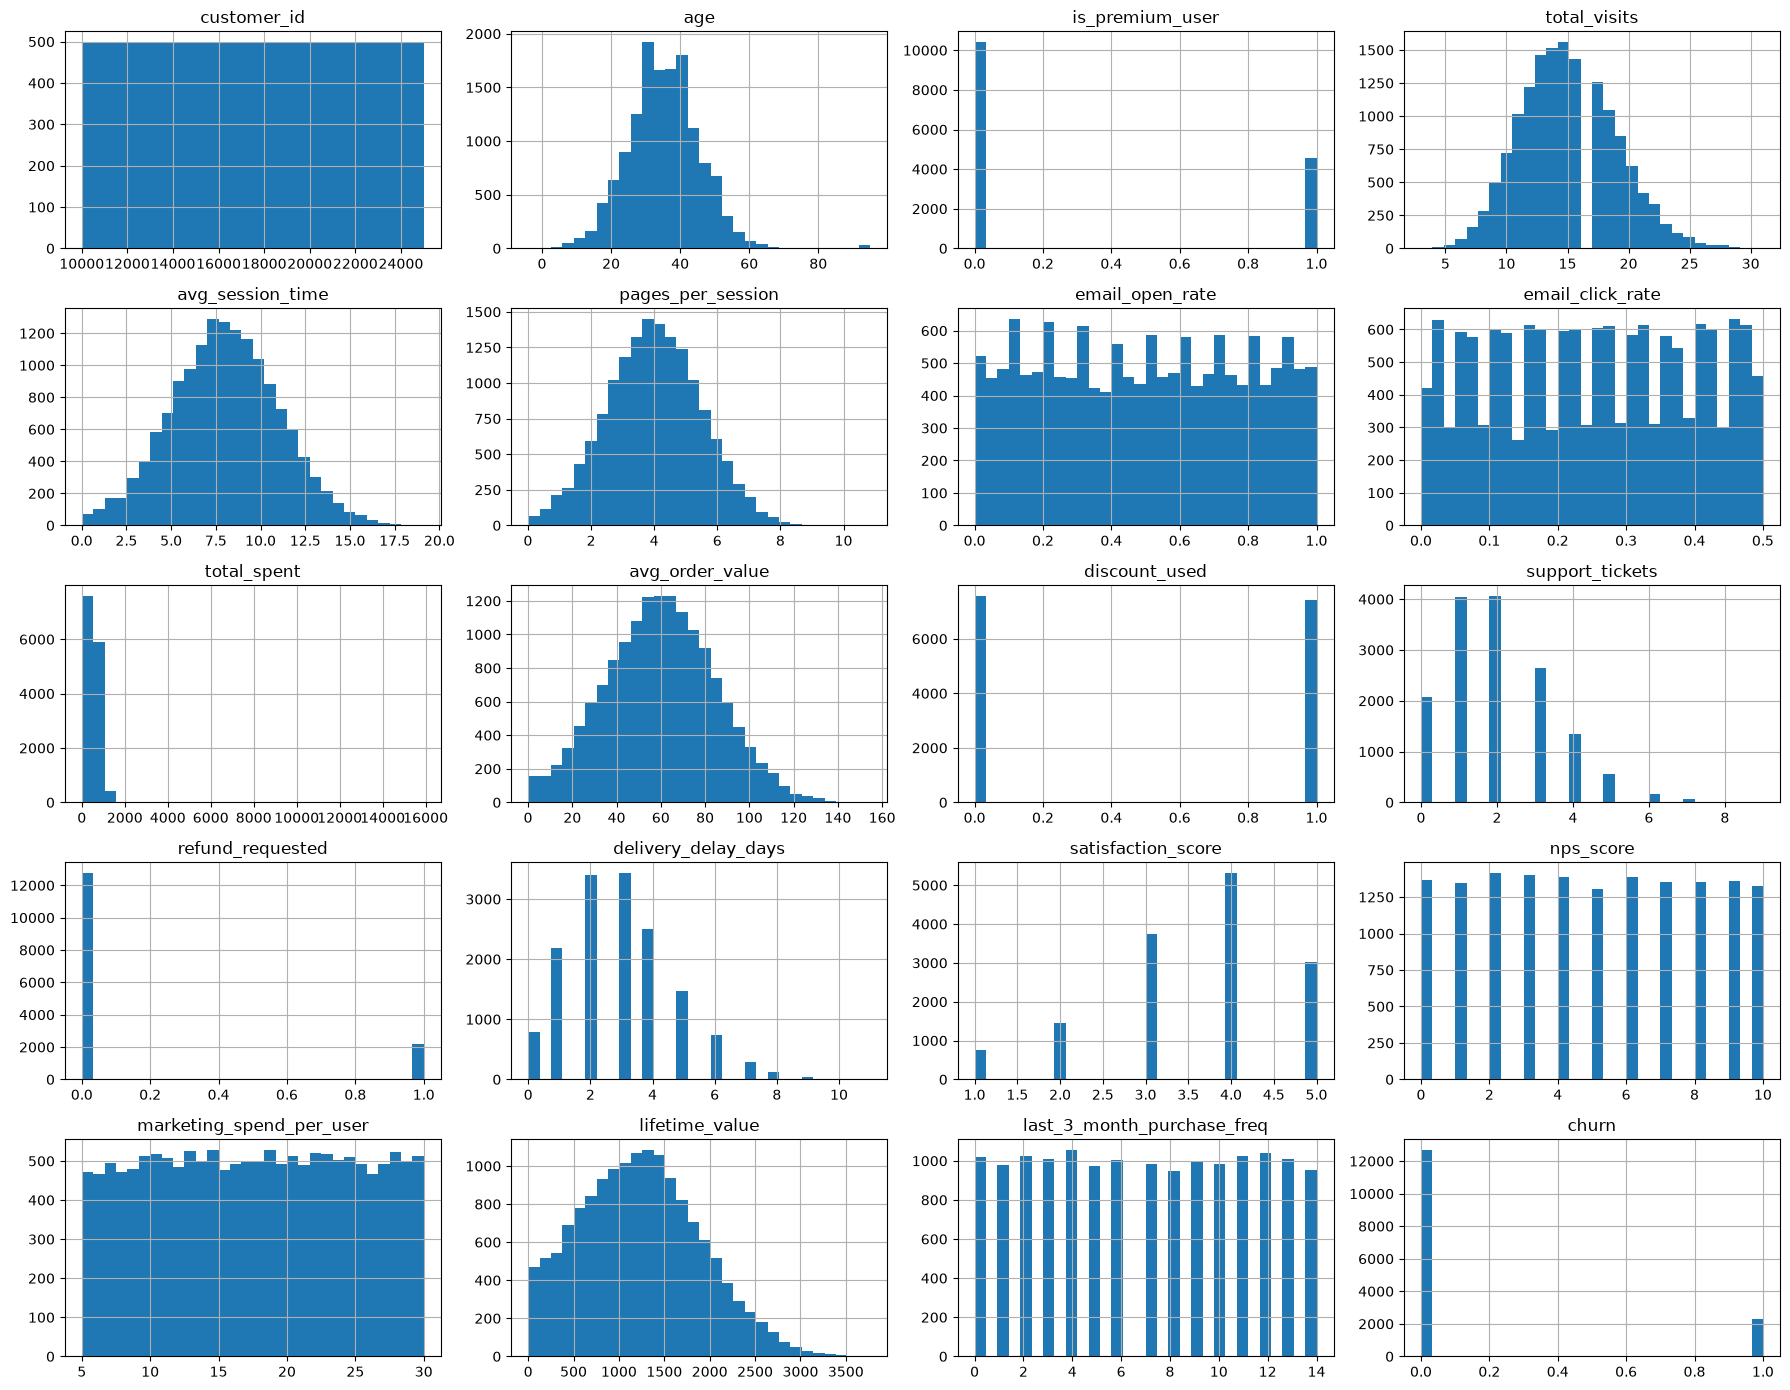

In [11]:
df[numeric_cols].hist(
    figsize=(18, 14),
    bins=30
)

plt.tight_layout()
plt.show()

And for boxplots as shown below,,,

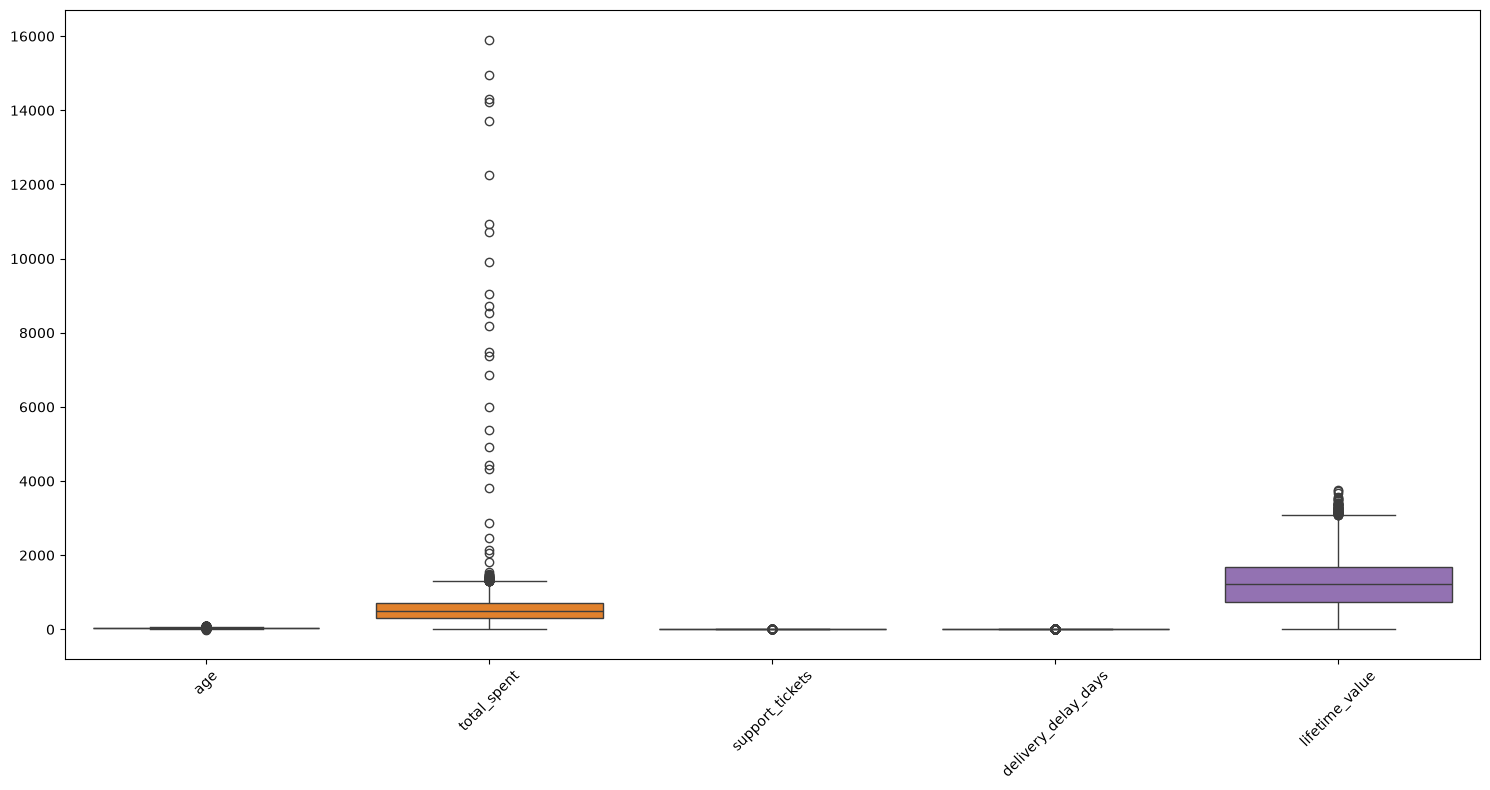

In [12]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df[
        [
            "age",
            "total_spent",
            "support_tickets",
            "delivery_delay_days",
            "lifetime_value"
        ]
    ]
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The boxplots have been put intentionally stretched down so as to show clearly the outliers

Investing inconsistent data types

In [13]:
print(df.dtypes)

customer_id                            int64
gender                                object
age                                  float64
country                               object
city                                  object
signup_date                   datetime64[ns]
last_purchase_date            datetime64[ns]
acquisition_channel                   object
device_type                           object
subscription_type                     object
is_premium_user                        int64
total_visits                           int64
avg_session_time                     float64
pages_per_session                    float64
email_open_rate                      float64
email_click_rate                     float64
total_spent                          float64
avg_order_value                      float64
discount_used                          int64
coupon_code                           object
support_tickets                        int64
refund_requested                       int64
delivery_d

Since we observed them and see some need conversions then we convert as seen below,,,

In [14]:
df["signup_date"] = pd.to_datetime(
    df["signup_date"],
    errors="coerce"
)

df["last_purchase_date"] = pd.to_datetime(
    df["last_purchase_date"],
    errors="coerce"
)

And just to be sure, we check

In [15]:
print(df[["signup_date", "last_purchase_date"]].dtypes)

signup_date           datetime64[ns]
last_purchase_date    datetime64[ns]
dtype: object


And as we can see, the date is back to it's datetime format 

Investigate duplicated records
Since from the past cell showing duplicates we didn't see any duplicates thus there's no need to investigate again the duplicate records, but just for the record it's proven below,,, 

In [16]:
print(
    "Duplicated rows:",
    df.duplicated().sum()
)

print(
    "Duplicated customer IDs:",
    df["customer_id"].duplicated().sum()
)

Duplicated rows: 0
Duplicated customer IDs: 0


As we can see there are no duplicates

Investing class imbalance

In [17]:
print(df["churn"].value_counts())

print(
    df["churn"]
    .value_counts(normalize=True)
    .mul(100)
)

churn
0    12702
1     2298
Name: count, dtype: int64
churn
0    84.68
1    15.32
Name: proportion, dtype: float64


To see exactly what we're dealing with, it's better to visualize

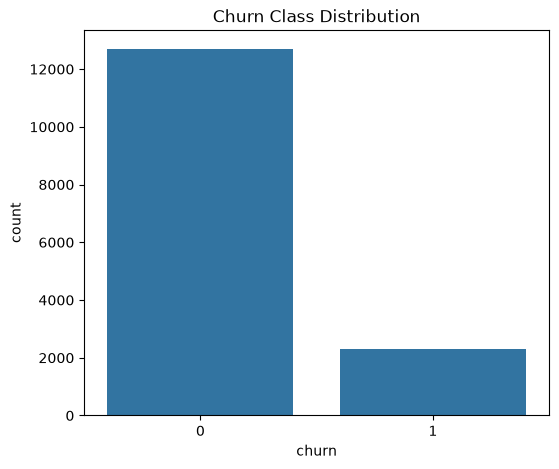

In [18]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Churn Class Distribution")
plt.show()

From the above visual we can see clearly that the churn class distribution is imbalanced by 84.68% to 15.32% that's quite imbalanced

Determining predictor variables

In [19]:
TARGET = "churn"

Our target is churn and also using customer_id would be a mistake since it's merely an identifier thus our predictor variables are as follows,
gender,
age,
country,
city,
acquisition_channel,
device_type,
subscription_type,
is_premium_user,
total_visits,
avg_session_time,
pages_per_session,
email_open_rate,
email_click_rate,
total_spent,
avg_order_value,
discount_used,
coupon_code,
support_tickets,
refund_requested,
delivery_delay_days,
payment_method,
satisfaction_score,
nps_score,
marketing_spend_per_user,
lifetime_value, and
last_3_month_purchase_freq

Identifying possible leakage variables

The most suspicious looking leakage variables include
last_purchase_date,
last_3_month_purchase_freq,
support_tickets,
refund_requested,
satisfaction_score, and 
nps_score

The only reason is that suppose the company defines churn using future customer behavior, then variables recorded after the prediction point could leak information about the outcome.
For example the "last_purchase_date" column tells the model exactly that on a certain date a customer stopped purchasing now that's cheating 

Exploratory data analysis

A.Churn by subscription

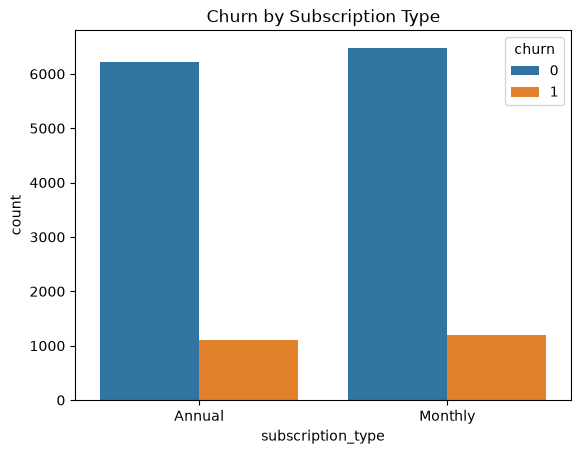

In [20]:
sns.countplot(
    data=df,
    x="subscription_type",
    hue="churn"
)

plt.title("Churn by Subscription Type")
plt.show()

The above plot shows churn by subscription type 0 and 1 between annual and monthly

B.Churn by acquisition channel

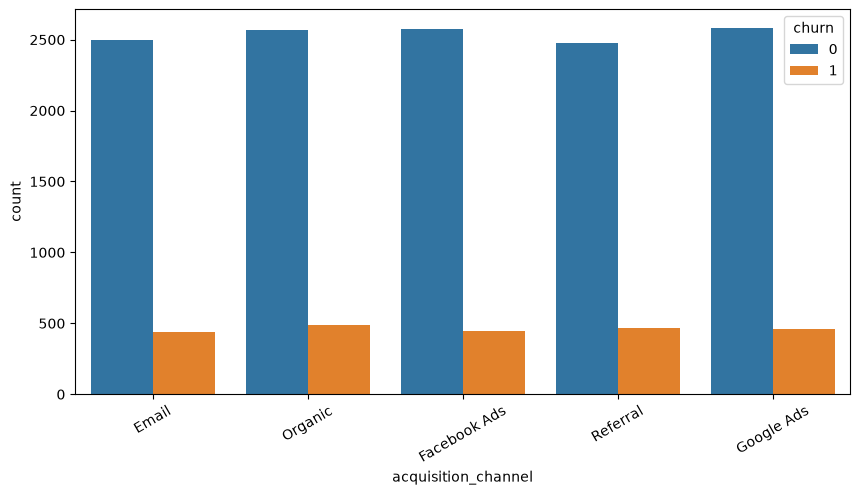

In [21]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="acquisition_channel",
    hue="churn"
)

plt.xticks(rotation=30)
plt.show()

The above plot shows churn by acquisition channel as shown above

C.Satisfaction by churn

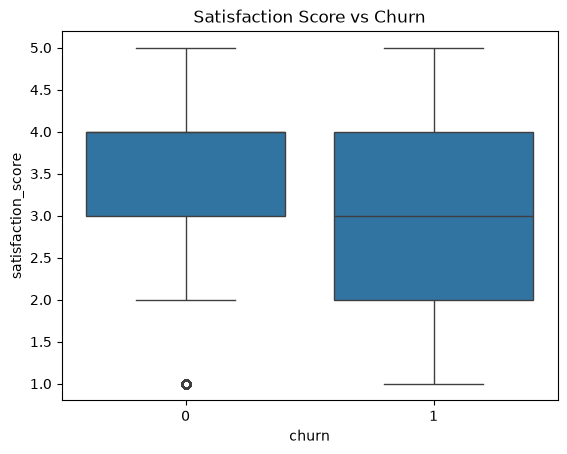

In [22]:
sns.boxplot(
    data=df,
    x="churn",
    y="satisfaction_score"
)

plt.title("Satisfaction Score vs Churn")
plt.show()

The above plot shows the satisfaction score by churn

D.Total spending vs churn

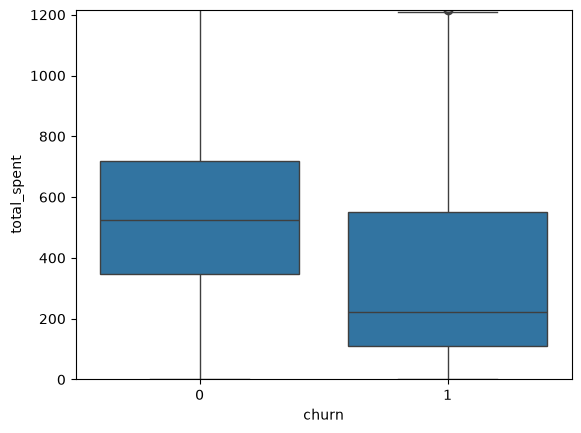

In [23]:
sns.boxplot(
    data=df,
    x="churn",
    y="total_spent"
)

plt.ylim(0, df["total_spent"].quantile(.99))

plt.show()

The above plot shows the boxplots of total spending vs churn we can see how they are set

Showing the engineered features

In [24]:
def engineer_features(data):

    df = data.copy()

    # Data conversion
    df["signup_date"] = pd.to_datetime(
        df["signup_date"],
        errors="coerce"
    )

    df["last_purchase_date"] = pd.to_datetime(
        df["last_purchase_date"],
        errors="coerce"
    )

    # Data-quality indicators

    df["age_invalid"] = (
        (df["age"] < 18) |
        (df["age"] > 100)
    ).astype(int)

    df.loc[
        df["age_invalid"] == 1,
        "age"
    ] = np.nan

    df["chronology_invalid"] = (
        df["signup_date"] >
        df["last_purchase_date"]
    ).astype(int)

    # Date features

    reference_date = pd.Timestamp("2025-03-11")

    df["tenure_days"] = (
        df["last_purchase_date"] -
        df["signup_date"]
    ).dt.days

    df.loc[
        df["tenure_days"] < 0,
        "tenure_days"
    ] = np.nan

    df["recency_days"] = (
        reference_date -
        df["last_purchase_date"]
    ).dt.days

    df["signup_year"] = (
        df["signup_date"].dt.year
    )

    df["signup_month"] = (
        df["signup_date"].dt.month
    )

    df["last_purchase_month"] = (
        df["last_purchase_date"].dt.month
    )

    # Behavioral features

    df["purchase_freq_per_month"] = (
        df["last_3_month_purchase_freq"] / 3
    )

    df["spend_per_visit"] = (
        df["total_spent"] /
        df["total_visits"].replace(0, np.nan)
    )

    df["session_depth"] = (
        df["avg_session_time"] *
        df["pages_per_session"]
    )

    df["spend_frequency_value"] = (
        df["avg_order_value"] *
        df["last_3_month_purchase_freq"]
    )

    df["support_refund_burden"] = (
        df["support_tickets"] +
        df["refund_requested"]
    )

    df["spend_to_marketing_ratio"] = (
        df["total_spent"] /
        df["marketing_spend_per_user"]
        .replace(0, np.nan)
    )

    df["email_engagement"] = (
        df["email_open_rate"] *
        df["email_click_rate"]
    )

    df["lifetime_value_per_tenure_month"] = (
        df["lifetime_value"] /
        (df["tenure_days"] / 30.44).clip(lower=1)
    )

    # Removing identifier and raw dates
    df = df.drop(
        columns=[
            "customer_id",
            "signup_date",
            "last_purchase_date",
            "churn"
        ]
    )

    return df

For the engineered features, we now have
tenure_days,
recency_days,
purchase_freq_per_month,
spend_per_visit,
session_depth,
spend_frequency_value,
support_refund_burden,
spend_to_marketing_ratio,
email_engagement, and 
lifetime_value_per_tenure_month

Preparing x and y for model training

In [25]:
X = engineer_features(df)

y = df["churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15000, 41)
y shape: (15000,)


Train Test split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(12000, 41)
(3000, 41)


From the outcome we now have 80% of the overall dataset for the training purpose and the remaining 20% for the testing purpose of our model and numerically that is 12000 rows for the training purpose and 3000 for the testing purpose

Now the preprocessing pipeline

The preprocessing is done to ensure there is no preprocessing data leakage

In [27]:
categorical_features = (
    X.select_dtypes(include=["object"]).columns
)

numeric_features = (
    X.select_dtypes(
        exclude=["object"]
    ).columns
)

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

Now for the feature selection

We can use L1-regularized logistic regression for feature selection.

In [28]:
feature_selector = SelectFromModel(
    LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    threshold="median"
)

The selection occurs inside the pipeline, meaning the test data never influences which features are selected.

Training the models

we will train the four models which are:
Logistic Regression,
Random Forest,
Gradient Boosting, and lastly
HistGradientBoosting

In [29]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),

    "Hist Gradient Boosting":
        HistGradientBoostingClassifier(
            max_iter=150,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        )
}

Training and comparing the four models

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    probability = pipeline.predict_proba(
        X_test
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),
        "Precision": precision_score(
            y_test,
            prediction
        ),
        "Recall": recall_score(
            y_test,
            prediction
        ),
        "F1": f1_score(
            y_test,
            prediction
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            probability
        ),
        "PR_AUC": average_precision_score(
            y_test,
            probability
        )
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "ROC_AUC",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,Gradient Boosting,0.859000,0.557632,0.389130,0.458387,0.920728,0.551829
1,Random Forest,0.854667,0.596774,0.160870,0.253425,0.919147,0.540336
3,Hist Gradient Boosting,0.841333,0.480296,0.423913,0.450346,0.910546,0.508526
0,Logistic Regression,0.750333,0.349948,0.732609,0.473647,0.826187,0.423862


From the output cell we notice that Random Forest has excellent ROC-AUC but terrible recall at the default 0.5 threshold.
And also we notice better accuracies but other poor perfomancies on other tests like the F1 and recall, thus tuning is required to overcome this

Cross-validation and hyperparameter tuning

Using stratified cross-validation

In [31]:
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic regression tuning

In [32]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_params = {
    "model__C": [
        0.01,
        0.1,
        1,
        10
    ]
}

logistic_search = GridSearchCV(
    logistic_pipeline,
    logistic_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

logistic_search.fit(
    X_train,
    y_train
)

print(
    logistic_search.best_params_
)

print(
    logistic_search.best_score_
)

{'model__C': 0.1}
0.8260898686343096


Random forest tuning

In [33]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_params = {
    "model__n_estimators": [
        200,
        300
    ],

    "model__max_depth": [
        8,
        12,
        20,
        None
    ],

    "model__min_samples_leaf": [
        1,
        3,
        5
    ],

    "model__max_features": [
        "sqrt",
        "log2"
    ]
}

rf_search = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_search.fit(
    X_train,
    y_train
)

print(
    rf_search.best_params_
)

print(
    rf_search.best_score_
)

{'model__max_depth': 12, 'model__max_features': 'log2', 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
0.9081448101367178


Gradient Boosting tuning

In [34]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_params = {
    "model__n_estimators": [
        100,
        150,
        200
    ],

    "model__learning_rate": [
        0.03,
        0.05,
        0.1
    ],

    "model__max_depth": [
        2,
        3,
        4
    ],

    "model__min_samples_leaf": [
        2,
        5
    ]
}

gb_search = GridSearchCV(
    gb_pipeline,
    gb_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

gb_search.fit(
    X_train,
    y_train
)

print(
    gb_search.best_params_
)

print(
    gb_search.best_score_
)

{'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
0.9106060906312916


HistGradient Boosting tuning

In [35]:
hist_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(
        random_state=42
    ))
])

hist_params = {
    "model__learning_rate": [
        0.03,
        0.05,
        0.1
    ],

    "model__max_iter": [
        100,
        150,
        200
    ],

    "model__max_leaf_nodes": [
        15,
        31,
        63
    ],

    "model__l2_regularization": [
        0,
        1,
        5
    ]
}

hist_search = GridSearchCV(
    hist_pipeline,
    hist_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

hist_search.fit(
    X_train,
    y_train
)

print(
    hist_search.best_params_
)

print(
    hist_search.best_score_
)

{'model__l2_regularization': 0, 'model__learning_rate': 0.1, 'model__max_iter': 100, 'model__max_leaf_nodes': 15}
0.9149097492813663


now after tuning the models for better perfomances we then compare the appropriate evaluation metrics

In [36]:
searches = {
    "Logistic Regression": logistic_search,
    "Random Forest": rf_search,
    "Gradient Boosting": gb_search,
    "Hist Gradient Boosting": hist_search
}

final_results = []

for name, search in searches.items():

    model = search.best_estimator_

    probability = model.predict_proba(
        X_test
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    final_results.append({
        "Model": name,
        "ROC_AUC": roc_auc_score(
            y_test,
            probability
        ),
        "PR_AUC": average_precision_score(
            y_test,
            probability
        ),
        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),
        "Precision": precision_score(
            y_test,
            prediction
        ),
        "Recall": recall_score(
            y_test,
            prediction
        ),
        "F1": f1_score(
            y_test,
            prediction
        )
    })

final_results = pd.DataFrame(
    final_results
)

display(
    final_results.sort_values(
        "PR_AUC",
        ascending=False
    )
)

,Model,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1
1,Random Forest,0.916325,0.528911,0.854333,0.513609,0.943478,0.665134
2,Gradient Boosting,0.916302,0.528804,0.854000,0.549107,0.267391,0.359649
3,Hist Gradient Boosting,0.916409,0.524029,0.852000,0.519608,0.460870,0.488479
0,Logistic Regression,0.826512,0.424019,0.751667,0.352941,0.743478,0.478656


we then tune the threshold we don't just use "Probability => 0.5" blindly we actually find  the threshold that maximizes F1 on the validation set,

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

final_model = gb_search.best_estimator_

final_model.fit(
    X_tr,
    y_tr
)

val_probability = final_model.predict_proba(
    X_val
)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_val,
    val_probability
)

f1_scores = (
    2 * precision * recall /
    (precision + recall + 1e-10)
)

best_index = np.argmax(
    f1_scores[:-1]
)

best_threshold = thresholds[best_index]

print(
    "Best threshold:",
    best_threshold
)

print(
    "Validation F1:",
    f1_scores[best_index]
)

Best threshold: 0.36697790712111455
Validation F1: 0.6727941176022924


after tuning the perfomances of our models we then use them to evaluate the untouched test data set

In [38]:
test_probability = final_model.predict_proba(
    X_test
)[:, 1]

test_prediction = (
    test_probability >= best_threshold
).astype(int)

print(
    
        y_test,
        test_prediction
    )

9021     0
12759    0
1445     0
3970     0
14475    0
        ..
11020    1
9349     0
2403     0
158      0
684      0
Name: churn, Length: 3000, dtype: int64 [0 0 0 ... 1 0 0]


Error analysis

After evaluating the test data set we generate the confusion matrix

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    test_prediction
)

print(cm)

[[2114  426]
 [   7  453]]


Then visualize it

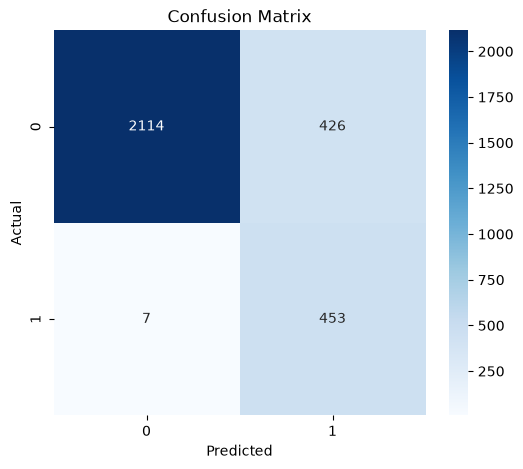

In [40]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Still on Error analysis, we analyze false positive and false negatives

In [41]:
error_analysis = X_test.copy()

error_analysis["actual"] = y_test.values

error_analysis["predicted"] = test_prediction

error_analysis["probability"] = test_probability

false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
]

false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
]

print(
    "False Negatives:",
    len(false_negatives)
)

print(
    "False Positives:",
    len(false_positives)
)

False Negatives: 7
False Positives: 426


Then we investigate them

In [42]:
display(
    false_negatives[
        [
            "age",
            "total_spent",
            "support_tickets",
            "satisfaction_score",
            "nps_score",
            "recency_days",
            "last_3_month_purchase_freq"
        ]
    ].describe()
)

,age,total_spent,support_tickets,satisfaction_score,nps_score,recency_days,last_3_month_purchase_freq
count,6.000000,7.000000,7.000000,5.000000,7.000000,7.000000,7.000000
mean,30.500000,169.482885,2.000000,3.400000,5.857143,449.571429,12.285714
std,10.858177,27.252101,1.290994,1.516575,2.911390,221.564029,0.755929
min,19.000000,131.262461,0.000000,1.000000,1.000000,150.000000,11.000000
25%,21.500000,149.453173,1.500000,3.000000,4.500000,301.000000,12.000000
50%,30.000000,167.920943,2.000000,4.000000,6.000000,396.000000,12.000000
75%,36.250000,194.161213,2.500000,4.000000,7.500000,619.500000,13.000000
max,47.000000,199.968020,4.000000,5.000000,10.000000,760.000000,13.000000


This helps us answer the question, What types of churners does the model fail to identify?

Interpreting the final model

By using the permutation importance

In [43]:
from sklearn.inspection import permutation_importance

# 1. Compute permutation importance on the full pipeline and raw test data
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# 2. Use raw feature names directly from X_test
importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

display(importance.head(20))

,Feature,Importance
21,satisfaction_score,0.183535
13,total_spent,0.084033
17,support_tickets,0.066342
38,spend_to_marketing_ratio,0.001877
9,avg_session_time,0.001496
32,last_purchase_month,0.000693
35,session_depth,0.000644
39,email_engagement,0.000524
40,lifetime_value_per_tenure_month,0.000353
8,total_visits,0.000345


Then we plot the model

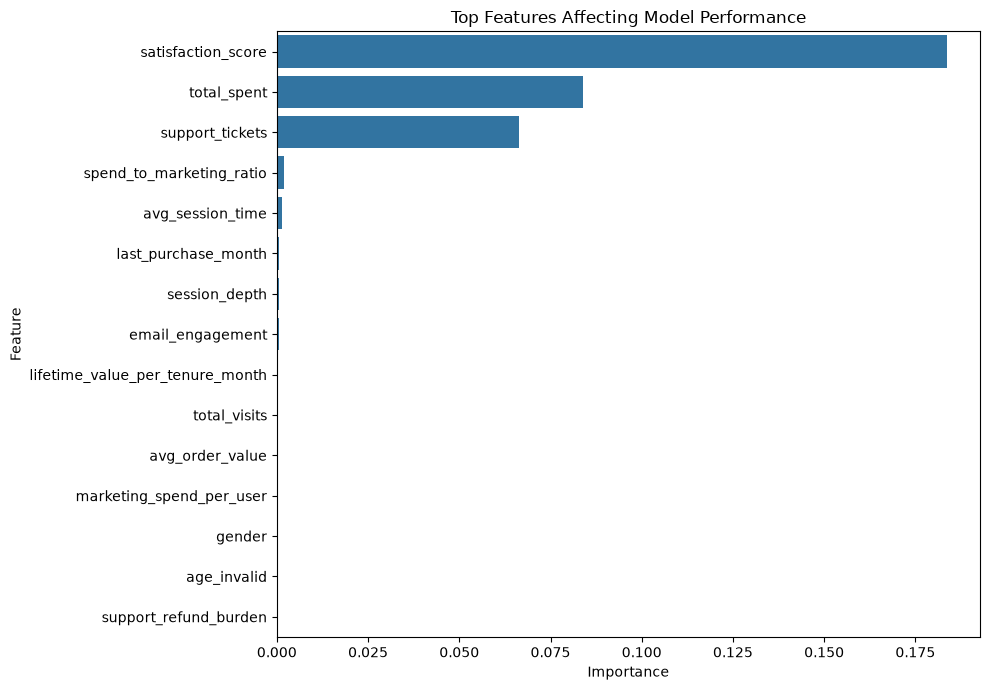

In [44]:
top_features = importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features Affecting Model Performance"
)

plt.tight_layout()

plt.show()

The interpretation gained from the plot shows that,, Permutation importance was used to identify the variables that most influenced predictive performance. The ranking shown in Figure X was obtained from the final fitted model

Saving the final model

In [45]:
final_model = gb_search.best_estimator_
final_model.fit(X_train, y_train)

print("Final model trained successfully.")

Final model trained successfully.


Saving and Deploying the model 

In [46]:
from pathlib import Path
import joblib

PROJECT_ROOT = Path.cwd()

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "final_model.joblib"

joblib.dump(final_model, MODEL_PATH)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
c:\Users\DINKA\BI\models\final_model.joblib
